# Startup

##Instructions to Run

1. Upload given example leaves to colab or other accessible place.
2. Edit code in "Import Images" cell a few cells below to correctly import desired number of images per type of leaf
3. Run all cells down to the classification section
4. Run desired classification sections to see results

In [1]:
# Computer Vision Course (CSE 40535)
#
# Semester Project -- Leaf Classification
#
# Author: Xavier Reese 2024
#
# Part 3 -- Pre-Processing, Segmentation & Feature Extraction

In [2]:
#@title Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
################
#@title Install
!apt-get install python3.5
#!pip uninstall -y opencv-python-headless opencv-python opencv-contrib-python
#!pip install opencv-python-headless==4.5.5.62+contrib-cuda -f https://download.opencv.org/releases.html
#!pip install opencv-python==4.8.1.78
!apt-get update
!apt-get install -y python3.5 # Install python 3.5 if needed by your project

# Install system dependencies for CUDA
!apt-get install -y --no-install-recommends \
    cuda-11-8 \
    libcublas-11-8 \
    libcudnn8

# Uninstall conflicting versions of OpenCV if they exist
!pip uninstall -y opencv-python-headless opencv-python opencv-contrib-python

# Install OpenCV with CUDA support
#!pip install opencv-python-headless==4.5.5.62+contrib-cuda -f https://download.opencv.org/releases.html
!pip install opencv-python-headless[cuda]

import numpy as np
import math
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import skimage.measure as measure

print(cv2.__version__)
print("CUDA Support in OpenCV:", cv2.cuda.getCudaEnabledDeviceCount() > 0)

testing_data = {}
unaltered_test_data = {}

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libpython3.5-stdlib' for regex 'python3.5'
Note, selecting 'libpython3.5-minimal' for regex 'python3.5'
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.
Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports

4.10.0
CUDA Support in OpenCV: False


In [35]:
#@title IMPORT IMAGES

import glob
images_per_type = 1000

orig_leaves = {}
path = "/content/drive/MyDrive/healthy/*" ### <=== UPDATE THIS TO DESIRED FOLDER
for folder in glob.glob(path):
    folder_name = folder.split('/')[-1]
    print('importing: ', folder_name)
    orig_leaves[folder_name] = []
    i = 0
    for img in glob.glob(folder+"/*"):
        i+=1
        if(i%100 == 0): print(i)
        if(i == images_per_type): break ### <==== Update this to desired amount
        orig_leaves[folder_name].append(cv2.imread(img))
    print('-- done --')

importing:  Apple
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Cherry
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Soybean
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Pepper
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Grape
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Peach
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Blueberry
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Raspberry
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Potato
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Strawberry
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Tomato
100
200
300
400
500
600
700
800
900
1000
-- done --


Separating and Augmenting...
Augmenting:  Apple
Augmenting:  Cherry
Augmenting:  Soybean
Augmenting:  Pepper
Augmenting:  Grape
Augmenting:  Peach
Augmenting:  Blueberry
Augmenting:  Raspberry
Augmenting:  Potato
Augmenting:  Strawberry
Augmenting:  Tomato
Remaining Training Data (per leaf type):  833
Separated Testing Data (per leaf type):  208
Augmented Image Examples:


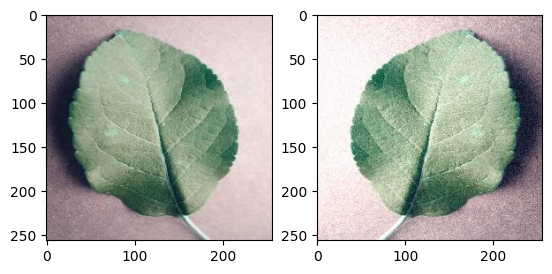

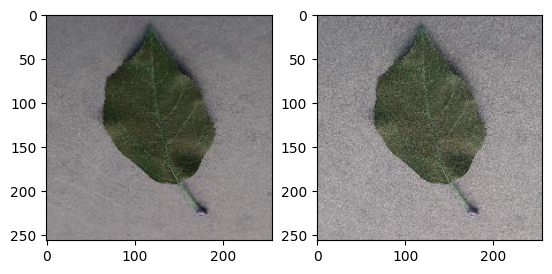

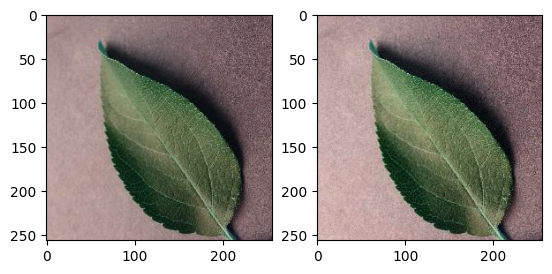

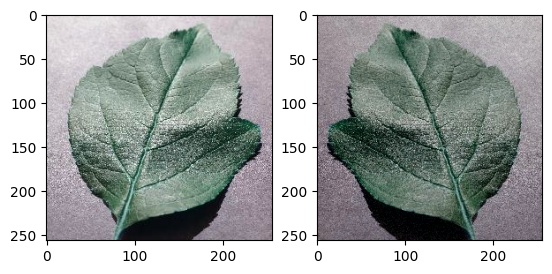

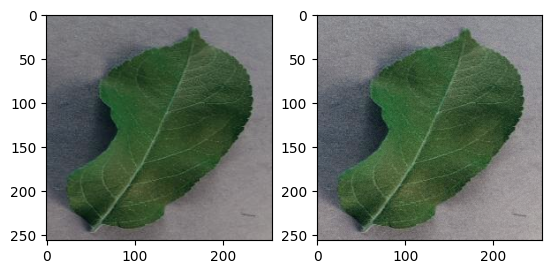

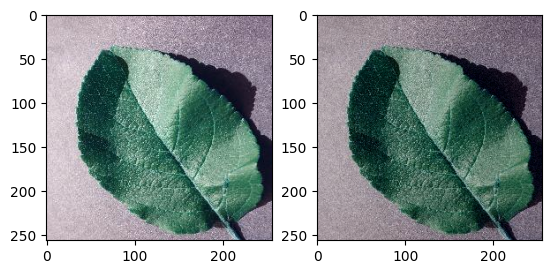

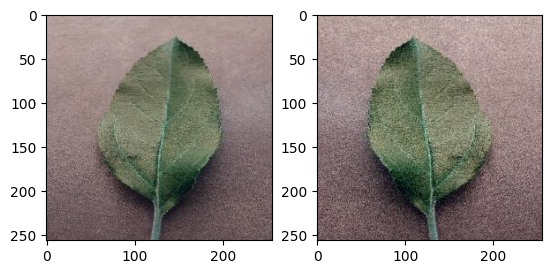

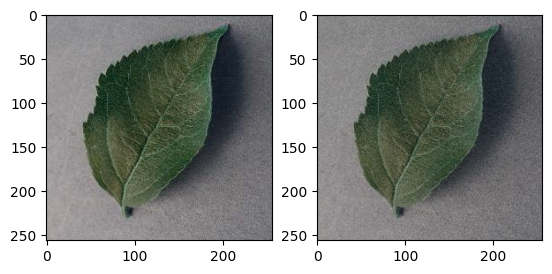

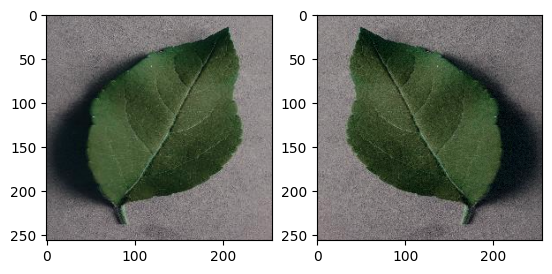

In [106]:
#@title Image Editing (Testing set)
from imgaug import augmenters as iaa
import os
import random


def load_images_from_folder(folder_path):
    images = []
    filenames = []
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path)
        if img is not None:
            images.append(img)
            filenames.append(filename)
    return images, filenames

def augment_image(image):
    seq = iaa.Sequential([
        iaa.Fliplr(0.5),
        iaa.AdditiveGaussianNoise(scale=(0, 0.05*255)),
        iaa.Multiply((0.8, 1.2)),
        iaa.LinearContrast((0.8, 1.2))
    ])
    augmented_image = seq(image=image)
    return augmented_image

def separate_and_augment(image_dict):
    print("Separating and Augmenting...")
    for leaf_type, images in image_dict.items():
        print("Augmenting: ", leaf_type)
        num_test_images = int(0.2 * len(images))
        test_indices = random.sample(range(len(images)), num_test_images)

        test_set = [images[i] for i in test_indices]
        unaltered_test_data[leaf_type] = test_set
        not_augmented = [images[i] for i in range(len(images)) if i not in test_indices]

        testing_data[leaf_type] = [augment_image(img) for img in test_set]
        image_dict[leaf_type] = not_augmented  # Update to keep only unaugmented data for training

if(len(orig_leaves["Apple"]) != images_per_type and bool(unaltered_test_data)): # Restore Testing Data to unaltered state if needed
    for leaf_type in orig_leaves.keys():
        orig_leaves[leaf_type] += unaltered_test_data[leaf_type]

separate_and_augment(orig_leaves)
print("Remaining Training Data (per leaf type): ", len(orig_leaves["Apple"]))
print("Separated Testing Data (per leaf type): ", len(testing_data["Apple"]))

print("Augmented Image Examples:")
for i in range(9):
    plt.subplot(1, 2, 1)
    plt.imshow(unaltered_test_data["Apple"][i])
    plt.subplot(1, 2, 2)
    plt.imshow(testing_data["Apple"][i])
    plt.show()

# Processing

In [107]:
#################################
#@title GENERAL USE HELPER FUNCTIONS

def equalize(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.equalizeHist(gray)

def equalize_clahe_gray(gray_img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(gray_img)

def equalize_clahe(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return equalize_clahe_gray(gray)


In [108]:
################################
#@title EXTRACT BINARY THRESH OF LEAF

def binary_leaf_green_rgb(image):
    r, g, b = cv2.split(image)
    # Threshold -> Binary of Leaf (green only)
    ret_leaf, thresh_leaf = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return ret_leaf, thresh_leaf

def binary_leaf_green_hsv(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    # Threshold -> Binary of Leaf (green only)
    lower_bounds = np.array([35, 20, 0])
    upper_bounds = np.array([100, 255, 255])
    mask = cv2.inRange(hsv, lower_bounds, upper_bounds)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel=np.ones((5,5), np.uint8))

    return mask

def binary_leaf_grey(image):
    gray = equalize(image)
    gray = equalize_clahe(image)
    # Threshold -> Binary of Leaf
    ret_leaf, thresh_leaf = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return ret_leaf, thresh_leaf

def binary_shadow(image):
    se_size = 2  # size of your structuring element (morphological operation kernel) -- try something between 5 and 15
    se = np.ones((se_size,se_size), np.uint8)
    gray = equalize_clahe(image)

    ret_shadow, thresh_shadow = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY_INV)

    # bounds for shadow
    shadow_lower_bounds = np.array([0, 0, 0])
    shadow_upper_bounds = np.array([255, 90, 30])

    # Erode & Dilate
    thresh_shadow = cv2.morphologyEx(thresh_shadow, cv2.MORPH_ERODE, kernel=se)
    thresh_shadow = cv2.morphologyEx(thresh_shadow, cv2.MORPH_DILATE, kernel=se)

    return ret_shadow, thresh_shadow




In [109]:
###################
#@title REMOVE SHADOWS

def shadow_mask(image):
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Threshold to isolate non-shadow areas (higher Value)
    _, mask = cv2.threshold(hsv_image[:, :, 2], 30, 255, cv2.THRESH_BINARY)

    #plt.imshow(mask, cmap='gray')
    #plt.show()
    return mask


In [110]:
#@title BINARY LEAF USING EDGE DETECTION

def edge_leaf_adaptive(image):
    blurred_image = cv2.GaussianBlur(image, (5, 5), 0)
    gray = cv2.cvtColor(blurred_image, cv2.COLOR_BGR2GRAY)
    adaptive_thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    median_blurred = cv2.medianBlur(adaptive_thresh, 7) # less noise
    edges = cv2.Canny(median_blurred, 50, 150)

    ## Show Adaptive Threshold Steps
    '''
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 4, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(adaptive_thresh, cmap='gray')
    plt.title("Adaptive Threshold")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(median_blurred, cmap='gray')
    plt.title("Median Blur")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(edges, cmap='gray')
    plt.title("Edges Detected")
    plt.axis("off")

    plt.show()
    '''

def edge_leaf(image):
    blurred_image = cv2.GaussianBlur(image, (5, 5), 0)
    gray = cv2.cvtColor(blurred_image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(blurred_image, threshold1=100, threshold2=200)
    without_shadow = cv2.bitwise_and(edges, shadow_mask(image))

    ## Show Edge Detection Steps
    '''
    plt.figure(figsize=(10,5))
    plt.subplot(1, 4, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(edges, cmap='gray')
    plt.title("Edges Detected")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(without_shadow, cmap='gray')
    plt.title("Without Shadows")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(gray, cmap='gray')
    plt.title("Gray Image")
    plt.axis("off")

    plt.show()
    '''

In [111]:
####################
#@title Post-Binarization

def remove_stems(img):
    kernel = np.ones((10, 10), np.uint8)
    opened_image = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(opened_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    leaf_bin = np.zeros_like(img)
    for contour in contours:
        if cv2.contourArea(contour) > 500:
            cv2.drawContours(leaf_bin, [contour], -1, 255, thickness=cv2.FILLED)
            break

    return leaf_bin

In [112]:
############################
#@title Extract Features

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

def extract_features(bin_img, orig_img):
    features = dict()

    contours, _ = cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    perimeter = cv2.arcLength(contours[0], True)
    with_perimeter = cv2.drawContours(orig_img.copy(), contours, -1, (0, 255, 0), 3)
    features['perimeter'] = perimeter

    c_hull = find_convex_hull(contours)
    features['area'] = cv2.contourArea(c_hull)
    features['perimeter'] = cv2.arcLength(c_hull, True)

    area_shape = cv2.contourArea(max(cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0], key=cv2.contourArea))
    features['solidity'] = float(area_shape) / features['area'] if features['area'] != 0 else 0

    features['major_axis_length'], features['minor_axis_length'] = major_minor_axis(bin_img, c_hull)
    features['aspect_ratio'] = features['major_axis_length'] / features['minor_axis_length']

    features.update(extract_texture_features(orig_img, bin_img))
    features.update(extract_color_features(orig_img, bin_img))

    return features

def find_convex_hull(contours):
    largest_contour = max(contours, key=cv2.contourArea)
    hull = cv2.convexHull(largest_contour)

    return hull

def major_minor_axis(bin_img, convex_hull):
    binary_convex = np.zeros_like(bin_img)
    cv2.drawContours(binary_convex, [convex_hull], -1, 255, thickness=cv2.FILLED)

    # Pad image so if binary leaf goes over edge, we don't get multiple labels for background

    binary_convex_padded = np.pad(binary_convex, pad_width=1, mode='constant', constant_values=0)
    labels_padded = measure.label(binary_convex_padded)
    labels = labels_padded[1:-1, 1:-1] # un-pad

    # Measure Features
    features = measure.regionprops(labels)

    return features[0].major_axis_length, features[0].minor_axis_length

def extract_color_features(orig_img, bin_img):
    leaf_region = cv2.bitwise_and(orig_img, orig_img, mask=bin_img)
    hsv = cv2.cvtColor(leaf_region, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    average_h = np.mean(h)
    average_s = np.mean(s)
    average_v = np.mean(v)

    return {'average_h': average_h, 'average_s': average_s, 'average_v': average_v}


def extract_texture_features(orig_img, bin_img):
    gray_image = cv2.cvtColor(orig_img, cv2.COLOR_BGR2GRAY)
    gray_image = equalize_clahe_gray(gray_image)
    leaf_region = cv2.bitwise_and(gray_image, gray_image, mask=bin_img)

    ## Plot shown in README
    #plt.subplot(2, 3, 5)
    #plt.imshow(leaf_region, cmap="gray")

    #gpu_leaf_region = cv2.cuda_GpuMat()
    #gpu_leaf_region.upload(leaf_region)

    ### Gray-Level Co-Occurrence Matrix (GLCM) Features

    distances = [1, 3, 5]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]  # 0, 45, 90, 135

    glcm = graycomatrix(leaf_region, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast').mean()
    dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()
    energy = graycoprops(glcm, 'energy').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    asm = graycoprops(glcm, 'ASM').mean()

    glcm_features = {'contrast': contrast, 'dissimilarity': dissimilarity, 'homogeneity': homogeneity, 'energy': energy, 'correlation': correlation, 'ASM': asm}

    ### Local Binary Pattern (LBP) Features

    radius = 3
    n_points = 8 * radius

    lbp = local_binary_pattern(leaf_region, n_points, radius, method="uniform")

    (lbpn, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    lbp_hist = lbpn.astype("float")
    lbp_hist /= (lbp_hist.sum())

    ### Gabor Filter Features

    num_orientations = 8

    gabor_means = []
    gabor_std = []
    filtered_max = np.zeros_like(bin_img)

    #height, width = bin_img.shape
    #gpu_filtered_or_img = cv2.cuda_GpuMat()
    #gpu_filtered_or_img.create((height, width), cv2.CV_8UC1)

    for theta in np.arange(0, np.pi, np.pi / num_orientations):
        if theta == np.pi / 4 or theta == 3 * np.pi / 4: continue  # skip 45 degree angles - much more difficult to tune and line features were picked up without them

        # Define Parameters
        sigma = 5
        ksize = 9 if theta == 0 or theta == np.pi / 2 else 13
        gamma = 0.01
        lambda_ = 5
        kernel = cv2.getGaborKernel((ksize, ksize), sigma, theta, 8.0, 0.5, 0, ktype=cv2.CV_32F)

        # Perform Filter
        filtered = cv2.filter2D(leaf_region, cv2.CV_8UC3, kernel)

        #gpu_filtered = cv2.cuda.filter2D(gpu_leaf_region, -1, cv2.cuda_Kernel(kernel))
        '''
        print("sigma", sigma, "theta", theta, "lambda", lambda_, "gamma", gamma, "ksize", ksize)
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(kernel, cmap='gray')
        plt.colorbar()
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(filtered, cmap='gray')
        plt.colorbar()
        plt.axis("off")
        plt.show()
        '''


        ## Max Results Together

        #filtered_and_bin = cv2.bitwise_or(filtered_and_bin, filtered, mask=bin_img)
        filtered_max = cv2.max(filtered_max, filtered)
        #gpu_filtered_or_img = cv2.cuda.bitwise_or(gpu_filtered_or_img, gpu_filtered, mask=gpu_leaf_region)
        mean, std_dev = cv2.meanStdDev(filtered, mask=bin_img)
        gabor_means.append(mean[0][0])
        gabor_std.append(std_dev[0][0])

    #filtered_max = gpu_filtered_or_img.download()

    ## Erode leaf edge and find mean/std of vein skeleton

    eroded_bin = cv2.erode(bin_img, np.ones((9, 9), np.uint8), iterations=1)
    filtered_max = cv2.bitwise_and(filtered_max, filtered_max, mask=eroded_bin)
    max_std, max_mean = cv2.meanStdDev(filtered_max, mask=eroded_bin)
    gabor_features = {'gabor_mean_sum': sum(gabor_means), 'gabor_std_sum': sum(gabor_std), 'gabor_mean_max': max_mean[0][0], 'gabor_std_max': max_std[0][0]}


    ## Show Vein Skeleton
    #cv2_imshow(filtered_max)

    ## Plot shown in README
    #plt.subplot(2, 3, 6)
    #plt.imshow(filtered_max, cmap="gray")

    all_features = {**glcm_features, **gabor_features, 'lbp_hist': lbp_hist}
    return all_features





In [113]:
#########################
#@title Final Functions

def binary_thresh_leaf(bin_img, orig_img):
    print("ORIGINAL:")
    cv2_imshow(bin_img)

    ret_leaf, thresh_leaf = binary_leaf_grey(bin_img)
    ret_shadow, thresh_shadow = binary_shadow(bin_img)

    #print("LEAF")
    #cv2_imshow(thresh_leaf)
    #print("SHADOW")
    #cv2_imshow(thresh_shadow)

    thresh = cv2.subtract(thresh_leaf, thresh_shadow)
    #print("FINAL")
    #cv2_imshow(thresh)

def binary_leaf_hsv(bin_img):
    #cv2_imshow(bin_img)
    green = binary_leaf_green_hsv(bin_img)
    #plt.subplot(2, 3, 2)
    #plt.imshow(green, cmap="gray")
    without_stems = remove_stems(green)
    return without_stems




# Extraction

In [114]:
########################
#@title Test / Display
import seaborn as sns
bin_images = []
bin_images_Y = []

leaf_data = dict()
def show(leaf_type):
    leaf_data[leaf_type] = []
    total = 30
    if leaf_type == 'Corn': return # removed because not in desired model behavior
    #if leaf_type != "Peach": return
    print(f'{leaf_type}')
    for i in range(total-1):
        img = orig_leaves[leaf_type][i].copy()
        bin_img = binary_leaf_hsv(img)
        bin_images.append(bin_img)
        bin_images_Y.append(leaf_type)
        leaf_data[leaf_type].append(extract_features(bin_img, img))

        ## Plot shown in README
        #plt.subplot(2, 3, 1)
        #plt.imshow(img)
        #plt.subplot(2, 3, 3)
        #plt.imshow(bin_img, cmap="gray")
    #plt.show()



for leaf_type in orig_leaves:
    show(leaf_type)

#   features_to_show = ['area', 'perimeter', 'solidity', 'major_axis_length', 'minor_axis_length', 'aspect_ratio', \
#                       'contrast', 'homogeneity', \
#                       'gabor_mean_max', 'gabor_std_max', 'average_h']
#   for feature_type in features_to_show:
#       plt.figure(figsize=(10, 5))
#       sns.boxplot(x=[key for key in leaf_data.keys() for _ in range(len(leaf_data[key]))], y=[value[feature_type] for key in leaf_data.keys() for value in leaf_data[key]])
#       plt.xlabel('Leaf Type')
#       plt.ylabel(feature_type)
#       plt.title(str(feature_type) + ' distribution by leaf type')
#       plt.show()
#   # display single lbp histogram
#   lbpn = leaf_data['Apple'][0]['lbp_hist']
#   plt.bar(range(len(lbpn)), lbpn)
#   plt.title("LBP HISTOGRAM")
#   plt.show()


Apple
Cherry
Soybean
Pepper
Grape
Peach
Blueberry
Raspberry
Potato
Strawberry
Tomato


# Classification

In [115]:
#@title Imports / Constants
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tensorflow.keras.callbacks import EarlyStopping

leaf_types = list(leaf_data.keys())  # ["apple", "grape", ... ]
type_to_label = {leaf_type: idx for idx, leaf_type in enumerate(leaf_types)}

batch_size = 16


In [63]:
#@title SVM Classification
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

results = []
X = []
Y = []
if('lbp_hist' in leaf_data['Apple'][0].keys()):
    for leaf_type, features in leaf_data.items():
        for feature in features:
            del feature['lbp_hist']

print(len(leaf_data['Apple'][0].keys()))

for leaf_type, features in leaf_data.items():
    X.extend(([list(f.values()) for f in features]))
    Y.extend([type_to_label[leaf_type]] * len(features))

X = np.array(X)
Y = np.array(Y)

'''
for pca_dim in [3]:
    print("PCA_DIM: ", pca_dim)
    pca = PCA(n_components=pca_dim)
    X_post = pca.fit_transform(X)
'''
scalar = StandardScaler()
X_post = scalar.fit_transform(X)

def fit(X_fit, y_fit, clf):
    X_train, X_test, y_train, y_test = train_test_split(X_fit, y_fit, test_size=0.3, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'RBF Accuracy on Leaves: {accuracy:.2f}')

fit(X_post, Y, SVC(kernel='rbf', decision_function_shape='ovr'))
del X
del Y
del X_post

19
RBF Accuracy on Leaves: 0.66


## Statistics -> Classification

In [ ]:
#@title Define Model
def train_model(pca_dim, data_x, data_y):
    print("PCA_DIM: ", pca_dim)
    #pca = PCA(n_components=pca_dim)
    #X_post = pca.fit_transform(data_x)
    scalar = StandardScaler()
    X_post = scalar.fit_transform(X)
    y_post = to_categorical(data_y)


    X_train, X_test, y_train, y_test = train_test_split(X_post, y_post, test_size=0.2, random_state=42)

    print(len(X_train))

    model = Sequential([
        Dense(64, input_dim=X_post.shape[1], activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(11, activation='softmax')
    ])

    model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

    history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=batch_size)


    loss, accuracy = model.evaluate(X_test, y_test)
    results.append([pca_dim, accuracy])



19
PCA_DIM:  2
255
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.0957 - loss: 2.4296 - val_accuracy: 0.3137 - val_loss: 2.1911
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4438 - loss: 2.0757 - val_accuracy: 0.3725 - val_loss: 1.9690
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5114 - loss: 1.8046 - val_accuracy: 0.5098 - val_loss: 1.7342
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5813 - loss: 1.4748 - val_accuracy: 0.5490 - val_loss: 1.5569
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6508 - loss: 1.1927 - val_accuracy: 0.6275 - val_loss: 1.4214
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6822 - loss: 1.0758 - val_accuracy: 0.6863 - val_loss: 1.3320
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7639 - loss: 0.8847 - val_accuracy: 0.6863 - val_loss: 1.3287
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6765 - loss: 0.8557 - val_accuracy: 0.7059 - val_loss: 1.2463
E

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.2311 - loss: 2.2727 - val_accuracy: 0.3922 - val_loss: 2.1050
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3715 - loss: 1.9469 - val_accuracy: 0.3922 - val_loss: 1.8822
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4628 - loss: 1.6663 - val_accuracy: 0.5882 - val_loss: 1.7157
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5017 - loss: 1.4749 - val_accuracy: 0.6078 - val_loss: 1.5523
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6455 - loss: 1.2892 - val_accuracy: 0.6471 - val_loss: 1.5021
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7546 - loss: 1.0224 - val_accuracy: 0.6275 - val_loss: 1.4209
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7093 - loss: 0.9429 - val_accuracy: 0.6667 - val_loss: 1.4030
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7722 - loss: 0.8862 - val_accuracy: 0.7059 - val_loss: 1.3403
E

...

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.1294 - loss: 2.3726 - val_accuracy: 0.1569 - val_loss: 2.2189
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4886 - loss: 2.0335 - val_accuracy: 0.4902 - val_loss: 1.9519
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5172 - loss: 1.7228 - val_accuracy: 0.5294 - val_loss: 1.7088
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5388 - loss: 1.4552 - val_accuracy: 0.5686 - val_loss: 1.6020
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6593 - loss: 1.1853 - val_accuracy: 0.6471 - val_loss: 1.4789
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7681 - loss: 0.9826 - val_accuracy: 0.6471 - val_loss: 1.3945
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7578 - loss: 0.9002 - val_accuracy: 0.7059 - val_loss: 1.3164
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7864 - loss: 0.7850 - val_accuracy: 0.6667 - val_loss: 1.3088
E

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.1710 - loss: 2.3520 - val_accuracy: 0.3333 - val_loss: 2.1823
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3831 - loss: 2.0552 - val_accuracy: 0.3529 - val_loss: 2.0278
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3906 - loss: 1.8547 - val_accuracy: 0.4510 - val_loss: 1.8375
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5572 - loss: 1.6287 - val_accuracy: 0.5098 - val_loss: 1.6535
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6204 - loss: 1.2837 - val_accuracy: 0.6275 - val_loss: 1.5012
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7409 - loss: 1.0804 - val_accuracy: 0.7255 - val_loss: 1.3753
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7448 - loss: 0.9798 - val_accuracy: 0.7451 - val_loss: 1.3161
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7232 - loss: 0.9242 - val_accuracy: 0.7451 - val_loss: 1.2219
E

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.1876 - loss: 2.3758 - val_accuracy: 0.3922 - val_loss: 2.1362
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3745 - loss: 1.9905 - val_accuracy: 0.5294 - val_loss: 1.9287
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5342 - loss: 1.6958 - val_accuracy: 0.6078 - val_loss: 1.7513
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6090 - loss: 1.4276 - val_accuracy: 0.5686 - val_loss: 1.5844
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6921 - loss: 1.2008 - val_accuracy: 0.6275 - val_loss: 1.4996
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7065 - loss: 1.0455 - val_accuracy: 0.6275 - val_loss: 1.4099
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6896 - loss: 0.9657 - val_accuracy: 0.6275 - val_loss: 1.3725
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7902 - loss: 0.8174 - val_accuracy: 0.6667 - val_loss: 1.3099
E

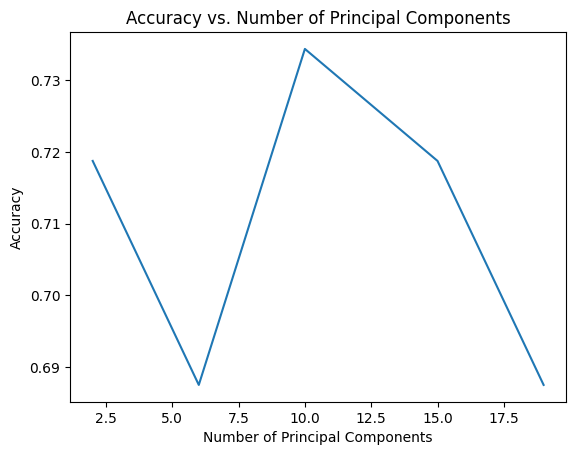

24495

In [ ]:
#@title Train Model
from tensorflow.keras import backend as K
import gc

K.clear_session()
gc.collect()


X = []
Y = []

if('lbp_hist' in leaf_data['Apple'][0].keys()):
    for leaf_type, features in leaf_data.items():
        for feature in features:
            del feature['lbp_hist']

print(len(leaf_data['Apple'][0].keys()))

for leaf_type, features in leaf_data.items():
    X.extend(([list(f.values()) for f in features]))
    Y.extend([type_to_label[leaf_type]] * len(features))

X = np.array(X)
Y = np.array(Y)

results = []
for pca_dim in [2, 6, 10, 15, 19]:
    train_model(pca_dim, X, Y)


results = np.array(results)
plt.plot(results[:, 0], results[:, 1])
plt.xlabel('Number of Principal Components')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Number of Principal Components')
plt.show()

del X
gc.collect()

## Processed Photo -> Classification

In [69]:
#@title Define Model
def train_model_post_process(data_x, data_y):
    print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
    y_post = to_categorical(data_y)

    X_train, X_test, y_train, y_test = train_test_split(data_x, y_post, test_size=0.2, random_state=42)

    input_shape = (256, 256, 1)

    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.8),
        Dense(11, activation='softmax')
    ])

    model.summary()

    model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    with tf.device('/GPU:0'):
        history = model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=batch_size, callbacks=[early_stopping])

    loss, accuracy = model.evaluate(X_test, y_test)

    return loss, accuracy

In [70]:
#@title Train Model
from tensorflow.keras import backend as K
import gc

K.clear_session()
gc.collect()
type_to_label = {leaf_type: idx for idx, leaf_type in enumerate(leaf_types)}

Y = []
for i in range(len(bin_images_Y)):
    Y.append(type_to_label[bin_images_Y[i]])



print("INPUT SHAPE:")
print(bin_images[0].shape)
bin_images_reshaped = np.array([cv2.resize(img, (256, 256)) for img in bin_images])
bin_images_reshaped = bin_images_reshaped.reshape(-1, 256, 256, 1)
bin_images_reshaped = bin_images_reshaped / 255.0
loss, accuracy = train_model_post_process(bin_images_reshaped, Y)

print(f"Loss: {loss}, Accuracy: {accuracy}")

del bin_images_reshaped
gc.collect()

INPUT SHAPE:
(256, 256)
Num GPUs Available:  1


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 246016)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │      15,745,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │             715 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,764,619 (60.14 MB)

 Trainable params: 15,764,619 (60.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.0770 - loss: 7.7947 - val_accuracy: 0.0392 - val_loss: 2.4007
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1475 - loss: 2.3654 - val_accuracy: 0.0784 - val_loss: 2.4031
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1384 - loss: 2.3224 - val_accuracy: 0.2549 - val_loss: 2.3650
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1597 - loss: 2.2238 - val_accuracy: 0.2353 - val_loss: 2.3026
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2263 - loss: 2.1457 - val_accuracy: 0.2549 - val_loss: 2.2792
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2145 - loss: 2.0797 - val_accuracy: 0.2941 - val_loss: 2.2278
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2781 - loss: 1.9712 - val_accuracy: 0.3333 - val_loss: 2.1383
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2263 - loss: 1.9483 - val_accuracy: 0.3333 - v

5147

## Original Images -> Classification

In [122]:
#@title Define Model
def train_model_original(data_x, data_y):
    print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
    y_post = to_categorical(data_y)

    X_train, X_test, y_train, y_test = train_test_split(data_x, y_post, test_size=0.2, random_state=42)

    print(len(X_train))

    input_shape = (256, 256, 1)

    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(11, activation='softmax')
    ])

    model.summary()

    model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    with tf.device('/GPU:0'):
        history = model.fit(X_train, y_train, validation_split=0.2, epochs=30, batch_size=batch_size, callbacks=[early_stopping])

    loss, accuracy = model.evaluate(X_test, y_test)

    aug_loss, aug_accuracy = model.evaluate(aug_X, to_categorical(aug_Y), verbose='auto')

    del model
    del history
    del X_train
    del X_test
    del y_train
    del y_test
    gc.collect()

    return loss, accuracy, aug_loss, aug_accuracy

In [123]:
#@title Organize Data
type_to_label = {leaf_type: idx for idx, leaf_type in enumerate(leaf_types)}
if('orig_X' in locals()):
    del orig_X
    del aug_X
    del Y
    gc.collect()
orig_X = []
Y = []

print("INPUT SHAPE:")
print(orig_leaves["Apple"][0].shape)
for leaf_type, leaves in orig_leaves.items():
    for leaf in leaves:
        orig_X.append(equalize(cv2.resize(leaf, (256, 256))))
        Y.append(type_to_label[leaf_type])

aug_X = []
aug_Y = []
for leaf_type, images in testing_data.items():
    for leaf in images:
        aug_X.append(equalize(cv2.resize(leaf, (256, 256))))
        aug_Y.append(type_to_label[leaf_type])

orig_X = np.array(orig_X)
aug_X = np.array(aug_X)
Y = np.array(Y)
aug_Y = np.array(aug_Y)

INPUT SHAPE:
(256, 256, 3)


In [124]:
#@title Train Model
from tensorflow.keras import backend as K
import gc

K.clear_session()
gc.collect()
orig_reshaped = orig_X.reshape(-1, 256, 256, 1)
orig_reshaped = orig_reshaped / 255.0
loss, accuracy, aug_loss, aug_accuracy = train_model_original(orig_reshaped, Y)

print(f"Loss: {loss}, Accuracy: {accuracy}")

print(f"Augmented Loss: {aug_loss}, Augmented Accuracy: {aug_accuracy}")

del orig_reshaped
del orig_X
del Y
gc.collect()

Num GPUs Available:  1
7330


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       6,422,592 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │             715 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,663,563 (25.42 MB)

 Trainable params: 6,663,563 (25.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
367/367 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.1468 - loss: 2.3585 - val_accuracy: 0.4638 - val_loss: 1.6060
Epoch 2/30
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4438 - loss: 1.5781 - val_accuracy: 0.6132 - val_loss: 1.1843
Epoch 3/30
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5638 - loss: 1.2016 - val_accuracy: 0.6535 - val_loss: 1.0067
Epoch 4/30
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6551 - loss: 0.9459 - val_accuracy: 0.7374 - val_loss: 0.8097
Epoch 5/30
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7344 - loss: 0.7463 - val_accuracy: 0.7203 - val_loss: 0.8399
Epoch 6/30
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7829 - loss: 0.6083 - val_accuracy: 0.7565 - val_loss: 0.7022
Epoch 7/30
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8153 - loss: 0.5063 - val_accuracy: 0.7851 - val_loss: 0.6806
Epoch 8/30
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8333 - loss: 0.4351 - val_accuracy: 0

0

## Original Images + Mask -> Classification

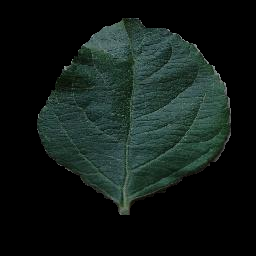

In [ ]:
#@title Organize Data with mask
if('orig_X_mask' in locals()):
    del orig_X_mask
    del Y_mask
    gc.collect()
orig_X_mask = []
Y_mask = []

for leaf_type, leaves in orig_leaves.items():
    for leaf in leaves:
        leaf_mask = binary_leaf_hsv(leaf)
        #leaf = equalize(leaf)
        dilated_leaf_mask = cv2.dilate(leaf_mask, np.ones((50, 50), np.uint8), iterations=1)
        leaf = cv2.bitwise_and(leaf, leaf, mask=leaf_mask)
        leaf = cv2.resize(leaf, (256, 256))
        orig_X_mask.append(leaf)
        Y_mask.append(type_to_label[leaf_type])

cv2_imshow(orig_X_mask[0])

orig_X_mask = np.array(orig_X_mask)
Y_mask = np.array(Y_mask)

In [ ]:
#@title Define Model
def train_model_original(data_x, data_y):
    print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
    y_post = to_categorical(data_y)

    X_train, X_test, y_train, y_test = train_test_split(data_x, y_post, test_size=0.2, random_state=42)

    print(len(X_train))

    input_shape = (256, 256, 3)

    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.7),
        Dense(11, activation='softmax')
    ])

    model.summary()

    model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    with tf.device('/GPU:0'):  # Specify GPU device
        history = model.fit(X_train, y_train, validation_split=0.2, epochs=40, batch_size=batch_size, callbacks=[early_stopping])

    loss, accuracy = model.evaluate(X_test, y_test)

    del model
    del history
    del X_train
    del X_test
    del y_train
    del y_test
    gc.collect()

    return loss, accuracy

In [ ]:
#@title Train Model
from tensorflow.keras import backend as K
import gc

K.clear_session()
gc.collect()
orig_reshaped = orig_X_mask.reshape(-1, 256, 256, 3)
orig_reshaped = orig_reshaped / 255.0
loss, accuracy = train_model_original(orig_reshaped, Y_mask)

print(f"Loss: {loss}, Accuracy: {accuracy}")
del orig_reshaped
del orig_X_mask
del Y_mask
gc.collect()

Num GPUs Available:  1
8791


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       6,422,592 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │             715 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,664,139 (25.42 MB)

 Trainable params: 6,664,139 (25.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.1834 - loss: 2.2992 - val_accuracy: 0.4099 - val_loss: 1.7211
Epoch 2/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3159 - loss: 1.8763 - val_accuracy: 0.5122 - val_loss: 1.4691
Epoch 3/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3960 - loss: 1.6484 - val_accuracy: 0.6055 - val_loss: 1.1873
Epoch 4/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4711 - loss: 1.4566 - val_accuracy: 0.6509 - val_loss: 1.0893
Epoch 5/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5294 - loss: 1.3085 - val_accuracy: 0.6760 - val_loss: 1.0137
Epoch 6/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5829 - loss: 1.1547 - val_accuracy: 0.7925 - val_loss: 0.6991
Epoch 7/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6381 - loss: 1.0022 - val_accuracy: 0.7840 - val_loss: 0.6976
Epoch 8/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6492 - loss: 0.9293 - val_acc

4720